In [1]:
from pathlib import Path
import pandas as pd

DATASET_ROOT = Path("/Users/amirsadra213/Desktop/MFT Class/Deep Learning/Food Detection/UECFOOD256")

SELECTED_CLASSES = {
    1: "rice",
    7: "sushi",
    9: "fried rice",
    12: "toast",
    13: "croissant",
    17: "hamburger",
    18: "pizza",
    19: "sandwiches",
    23: "ramen noodle",
    27: "spaghetti",
    30: "gratin",
    36: "miso soup",
    38: "sausage",
    40: "omelet",
    46: "grilled salmon",
    55: "fried chicken",
    61: "steak",
    68: "egg sunny-side up",
    80: "roast chicken",
    86: "potato salad",
    87: "green salad",
    94: "rice ball",
    97: "hot dog",
    98: "french fries",
    114: "pancake",
    123: "mushroom risotto",
    130: "chicken nugget",
    151: "scrambled egg",
    153: "lasagna",
    224: "brownie",
}

rows = []

for class_id, class_name in SELECTED_CLASSES.items():
    class_dir = DATASET_ROOT / str(class_id)
    bb_file = class_dir / "bb_info.txt"

    jpg_files = list(class_dir.glob("*.jpg"))
    jpeg_files = list(class_dir.glob("*.jpeg"))
    image_files = jpg_files + jpeg_files

    annotation_count = 0
    annotated_image_ids = set()

    if bb_file.exists():
        with open(bb_file, "r", encoding="utf-8", errors="ignore") as f:
            lines = f.readlines()

        for line in lines:
            line = line.strip()

            if not line:
                continue

            parts = line.split()

            # در UEC معمولاً:
            # image_id x1 y1 x2 y2
            if len(parts) >= 5 and parts[0].isdigit():
                annotation_count += 1
                annotated_image_ids.add(parts[0])

    rows.append({
        "uec_id": class_id,
        "class_name": class_name,
        "image_count": len(image_files),
        "bbox_count": annotation_count,
        "annotated_images": len(annotated_image_ids),
        "bb_info_exists": bb_file.exists()
    })

df = pd.DataFrame(rows)

print(df.to_string(index=False))

print("\nTotal images:", df["image_count"].sum())
print("Total bounding boxes:", df["bbox_count"].sum())

 uec_id        class_name  image_count  bbox_count  annotated_images  bb_info_exists
      1              rice          620         626               620            True
      7             sushi          153         161               153            True
      9        fried rice          169         169               169            True
     12             toast          218         224               218            True
     13         croissant          120         121               120            True
     17         hamburger          233         242               233            True
     18             pizza          134         134               134            True
     19        sandwiches          163         164               163            True
     23      ramen noodle          353         353               353            True
     27         spaghetti          151         151               151            True
     30            gratin          115         115               

In [2]:
bb_file = DATASET_ROOT / "27" / "bb_info.txt"

with open(bb_file, "r", encoding="utf-8", errors="ignore") as f:
    for _ in range(10):
        print(f.readline().strip())

img x1 y1 x2 y2
2593 0 7 289 279
2594 3 22 784 579
2595 32 18 399 300
2596 25 15 428 345
2597 60 36 440 347
2598 17 126 404 546
2599 22 39 460 327
2600 12 49 406 518
2601 61 61 626 477


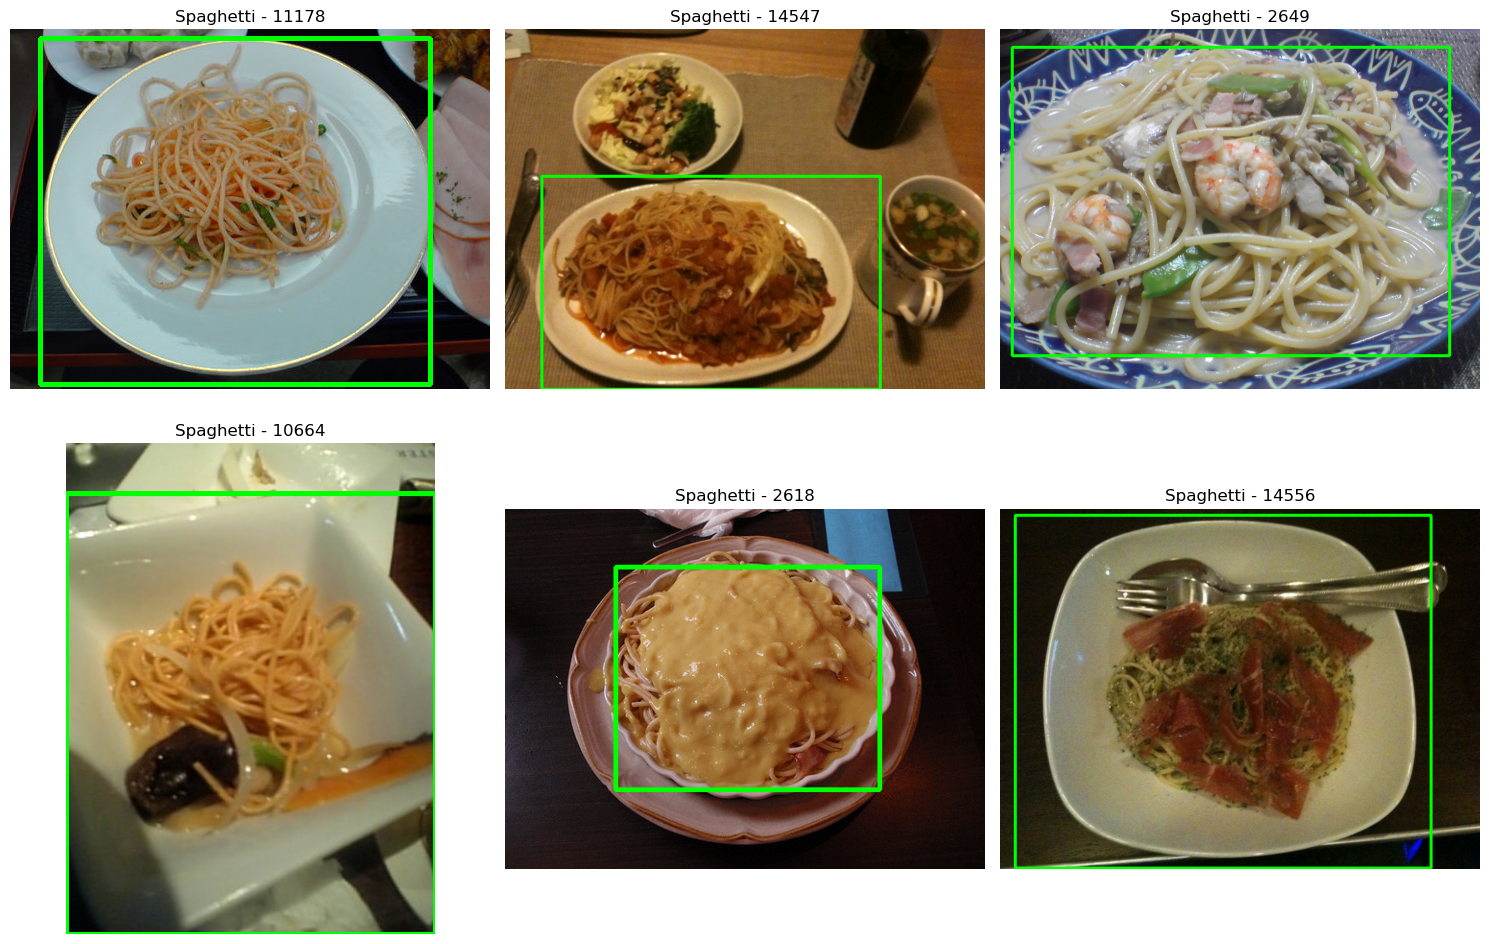

In [3]:
import cv2
import matplotlib.pyplot as plt
import random
from pathlib import Path

CLASS_ID = 27
class_dir = DATASET_ROOT / str(CLASS_ID)
bb_file = class_dir / "bb_info.txt"

# -------------------------
# Read annotations
# -------------------------

annotations = {}

with open(bb_file, "r", encoding="utf-8") as f:
    next(f)  # skip: img x1 y1 x2 y2

    for line in f:
        parts = line.strip().split()

        if len(parts) != 5:
            continue

        img_id, x1, y1, x2, y2 = parts

        annotations.setdefault(img_id, []).append(
            (int(x1), int(y1), int(x2), int(y2))
        )

# -------------------------
# Select random images
# -------------------------

available_ids = [
    img_id
    for img_id in annotations
    if (class_dir / f"{img_id}.jpg").exists()
]

sample_ids = random.sample(
    available_ids,
    min(6, len(available_ids))
)

# -------------------------
# Draw
# -------------------------

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, img_id in zip(axes, sample_ids):

    image_path = class_dir / f"{img_id}.jpg"

    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    for x1, y1, x2, y2 in annotations[img_id]:

        cv2.rectangle(
            image,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            3
        )

    ax.imshow(image)
    ax.set_title(f"Spaghetti - {img_id}")
    ax.axis("off")

plt.tight_layout()
plt.show()